Now that we have been able to recreate the perturbation theory results of the Ningyuang paper using just the Green's function approach, I feel that it would be a good idea to try applying it to our 3 level system.  We'll start by considering 1 atom with zero detunings, then add the detuning.  If that all works out, then we can move onto considering more than 1 atom.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym
from scipy import linalg
import time

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# Define parameters
Δ1 = 0
δc = 0
κ = 1
γ10 = 1
γ21 = 0.05
g10 = 7/2
g21 = 13/2
λ = 1e-3

In [4]:
# Define operators for defining H
a = qu.destroy(2)
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

# Define identity matrices over these spaces for convenience
Ic = qu.qeye(2)
Ia = qu.qeye(3)

I calculated the Hamiltonian in the RWA using projectors onto the relevant basis states.  This is perfectly fine, but it would be cumbersome to do for a large system.  It would be better if we could define the Hamiltonian in the full basis under the RWA and then just filter out the elements that correspond to the basis states we care about.  I want to confirm that that works out, so let's define a fixed value of $\delta_L$ as a test.

In [5]:
# Define the fixed δL for testing
δL = 0

In [6]:
# Define Hamiltonian using operators over the full basis
H = -1j*κ * qu.tensor(a.dag()*a, Ia) - (Δ1 + 1j*γ10) * qu.tensor(Ic, σ10.dag() * σ10)
H += -(δc + Δ1 + 1j*γ21) * qu.tensor(Ic, σ21.dag() * σ21)
H += g10 * (qu.tensor(Ic, σ10.dag()) + qu.tensor(Ic, σ10))
H

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0. +0.j   3.5+0.j   0. +0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [3.5+0.j   0. -1.j   0. +0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. -0.05j 0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. -1.j   3.5+0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   3.5+0.j   0. -2.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. +0.j   0. +0.j   0. -1.05j]]

In [7]:
# Define the interaction V
V = g21 * (qu.tensor(a, σ21.dag()) + qu.tensor(a.dag(), σ21))
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  6.5 0. ]
 [0.  0.  0.  0.  0.  0. ]
 [0.  0.  6.5 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0. ]]

In [8]:
# Define the drive V
#Vd = qu.tensor(qu.basis(2,1), qu.basis(3,0)) * qu.tensor(qu.basis(2,0), qu.basis(3,0)).dag()
#Vd += qu.tensor(qu.basis(2,1), qu.basis(3,1)) * qu.tensor(qu.basis(2,0), qu.basis(3,1)).dag()
#Vd += Vd.dag()
#Vd *= λ
Vd = λ * (qu.tensor(a.dag(), Ia) + qu.tensor(a, Ia))
Vd

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.    0.    0.    0.001 0.    0.   ]
 [0.    0.    0.    0.    0.001 0.   ]
 [0.    0.    0.    0.    0.    0.001]
 [0.001 0.    0.    0.    0.    0.   ]
 [0.    0.001 0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.    0.   ]]

In [9]:
# Now combine with the detuning terms involving δL
Ht = H + V + Vd + δL * qu.tensor(a * a.dag(), Ia)
Ht

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.0e+00+0.j   3.5e+00+0.j   0.0e+00+0.j   1.0e-03+0.j   0.0e+00+0.j
  0.0e+00+0.j  ]
 [3.5e+00+0.j   0.0e+00-1.j   0.0e+00+0.j   0.0e+00+0.j   1.0e-03+0.j
  0.0e+00+0.j  ]
 [0.0e+00+0.j   0.0e+00+0.j   0.0e+00-0.05j 0.0e+00+0.j   6.5e+00+0.j
  1.0e-03+0.j  ]
 [1.0e-03+0.j   0.0e+00+0.j   0.0e+00+0.j   0.0e+00-1.j   3.5e+00+0.j
  0.0e+00+0.j  ]
 [0.0e+00+0.j   1.0e-03+0.j   6.5e+00+0.j   3.5e+00+0.j   0.0e+00-2.j
  0.0e+00+0.j  ]
 [0.0e+00+0.j   0.0e+00+0.j   1.0e-03+0.j   0.0e+00+0.j   0.0e+00+0.j
  0.0e+00-1.05j]]

This is what I expect in that the terms involving $\delta_L$ are limited to the states with the cavity having no photons in it.  This does include the state $|1,2\rangle$, which we aren't really interested in, but it should be easy enough to filter this out as we have before.  First, we'll attempt to use the perturbation theory approach to calculate the transmission spectrum of this system.  This will require filtering out the states that represent having no cavity excitation from those that represent having exactly 1.

In [10]:
# Define the basis states for the cavity and the atom
cav_bas = [qu.basis(2, i) for i in range(2)]
atom_bas = [qu.basis(3, i) for i in range(3)]

In [11]:
# Define the basis states for Hu
Hu_bas = [qu.tensor(cav_bas[0], atom_bas[i]) for i in range(2)]

# Define the empty matrix
Hu_mat = np.zeros((len(Hu_bas), len(Hu_bas)), dtype=complex)
for i in range(len(Hu_bas)):
    for j in range(len(Hu_bas)):
        Hu_mat[i][j] = Hu_bas[i].dag() * (H + δL * qu.tensor(a * a.dag(), Ia)) * Hu_bas[j]

# Convert to qObj
Hu = qu.Qobj(Hu_mat)
Hu

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. +0.j 3.5+0.j]
 [3.5+0.j 0. -1.j]]

In [12]:
# Define the basis states for Hp
Hp_bas = [qu.tensor(cav_bas[1], atom_bas[i]) for i in range(2)]
Hp_bas.insert(0, qu.tensor(cav_bas[0], atom_bas[2]))

# Define the empty matrix
Hp_mat = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_mat[i][j] = Hp_bas[i].dag() * (H + δL * qu.tensor(a * a.dag(), Ia) + V) * Hp_bas[j]

# Convert to qObj
Hp = qu.Qobj(Hp_mat)
Hp

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. -0.05j 0. +0.j   6.5+0.j  ]
 [0. +0.j   0. -1.j   3.5+0.j  ]
 [6.5+0.j   3.5+0.j   0. -2.j  ]]

In [13]:
# We will need to do the same for the drive V if we want to multiply these matrices together
Vd_bas = Hu_bas + Hp_bas

# Define and fill the empty matrix
Vd_mat = np.zeros((len(Vd_bas), len(Vd_bas)), dtype=complex)
for i in range(len(Vd_bas)):
    for j in range(len(Vd_bas)):
        Vd_mat[i][j] = Vd_bas[i].dag() * Vd * Vd_bas[j]

# Convert to qObj
Vd_pt = qu.Qobj(Vd_mat)
Vd_pt

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.    0.    0.    0.001 0.   ]
 [0.    0.    0.    0.    0.001]
 [0.    0.    0.    0.    0.   ]
 [0.001 0.    0.    0.    0.   ]
 [0.    0.001 0.    0.    0.   ]]

In [14]:
# Now construct H0 for the perturbation theory from a direct sum of Hu and Hp
H0_mat = linalg.block_diag(Hu_mat, Hp_mat)

# Convert
H0_pt = qu.Qobj(H0_mat)
H0_pt

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. +0.j   3.5+0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [3.5+0.j   0. -1.j   0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. -0.05j 0. +0.j   6.5+0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. -1.j   3.5+0.j  ]
 [0. +0.j   0. +0.j   6.5+0.j   3.5+0.j   0. -2.j  ]]

In [15]:
# Get the eigenstates
H0_pt_eigs = H0_pt.eigenstates()
H0_pt_eigs

(array([-7.32052912e+00-1.13354261j, -3.46410162e+00-0.5j       ,
        -1.45623455e-17-0.78291478j,  3.46410162e+00-0.5j       ,
         7.32052912e+00-1.13354261j]),
 array([Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [-0.6143898 +0.09093844j]
         [-0.3379606 +0.00616515j]
         [ 0.70710678+0.j        ]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.69985421+0.10101525j]
         [ 0.70710678+0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.00000000e+00+0.00000000e+00j]
         [-0.00000000e+00+0.00000000e+00j]
      

In [16]:
test = H0_pt_eigs[1][1] + λ * (δL - H0_pt).inv() * Vd_pt * H0_pt_eigs[1][1]
test

Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
Qobj data =
[[-6.99854212e-01+1.01015254e-01j]
 [ 7.07106781e-01+0.00000000e+00j]
 [-1.60472298e-07-3.70594899e-07j]
 [ 9.66948464e-08+6.89876657e-07j]
 [ 2.85072999e-09-1.23440229e-09j]]

Okay, so this seems to work like it does in the single atom case for the most part.  Let's see what we get if we repeat this over a range of $\delta_L$ values.

Actually, I'm not sure that this is so straightforward.  In the Ningyuang system, the problem is set up so that $V_d|0,0\rangle = |1,0\rangle$.  Then you just multiply on the left by $\langle1,0|$ to get the transmission spectrum.  This works out just fine because the eigenstate of $H_u$ is $|0,0\rangle$.  Here, the eigenstates of $H_u$ are $\alpha|0,0\rangle + \beta|0,1\rangle$ and $\beta|0,0\rangle - \alpha|0,1\rangle$.  Thus, we get either $V|\epsilon_0\rangle = \alpha|1,0\rangle + \beta|1,1\rangle$ or $V|\epsilon_1\rangle = \beta|1,0\rangle - \alpha|1,1\rangle$.  As $\delta_L$ varies, the exact position of these eigenstates in the array and the values of $\alpha$ and $\beta$ will change.  I need some way of making sure that I'm always looking at the same eigenstate when I do the calculations.

In [17]:
# Define the δL values
δL = np.linspace(-50, 50, 500)

In [18]:
# Define the value of Hu at 0 detuning
Hu_0_mat = np.zeros((len(Hu_bas), len(Hu_bas)), dtype=complex)
for i in range(len(Hu_bas)):
    for j in range(len(Hu_bas)):
        Hu_0_mat[i][j] = Hu_bas[i].dag() * H * Hu_bas[j]

# Convert to qObj
Hu_0 = qu.Qobj(Hu_0_mat)

# Define the value of Hp at 0 detuning
Hp_0_mat = np.zeros((len(Hp_bas), len(Hp_bas)), dtype=complex)
for i in range(len(Hp_bas)):
    for j in range(len(Hp_bas)):
        Hp_0_mat[i][j] = Hp_bas[i].dag() * (H + V) * Hp_bas[j]

# Convert to qObj
Hp_0 = qu.Qobj(Hp_0_mat)
Hp_0

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. -0.05j 0. +0.j   6.5+0.j  ]
 [0. +0.j   0. -1.j   3.5+0.j  ]
 [6.5+0.j   3.5+0.j   0. -2.j  ]]

In [19]:
# Calculate overlaps with |1,0> and |1,1>
pt_ovlps_e0_10 = np.zeros(δL.shape[0], dtype=complex)
test = np.zeros(δL.shape[0], dtype=object)
test2 = np.zeros(δL.shape[0], dtype=object)
pt_ovlps_e0_11 = np.zeros(δL.shape[0], dtype=complex)
pt_ovlps_e1_10 = np.zeros(δL.shape[0], dtype=complex)
pt_ovlps_e1_11 = np.zeros(δL.shape[0], dtype=complex)
for i in range(δL.shape[0]):
    # Define temporary Hu and Hp with δL
    temp_Hu = Hu_0
    temp_Hp = Hp_0 + qu.Qobj([[0, 0, 0],
                              [0, 0, 0],
                              [0, 0, 0]])

    # Get eigenstates
    temp_eigs = temp_Hu.eigenstates()

    # Define the action of Vd on the eigenstates
    e0 = qu.Qobj([0, temp_eigs[1][0].full()[0][0], temp_eigs[1][0].full()[1][0]])
    e1 = qu.Qobj([0, temp_eigs[1][1].full()[0][0], temp_eigs[1][1].full()[1][0]])
    e2 = qu.Qobj([0, 0, 1])

    # Now calculate the overlaps
    pt_ovlps_e0_10[i] = qu.Qobj([0, 1, 0]).dag() * (δL[i] * qu.qeye(3) - temp_Hp).inv() * e0
    test[i] = (δL[i] + temp_eigs[0][0] * qu.qeye(3) - temp_Hp).inv() * e0
    pt_ovlps_e0_11[i] = qu.Qobj([0, 0, 1]).dag() * (δL[i] * qu.qeye(3) - temp_Hp).inv() * e0
    test2[i] = (δL[i] + temp_eigs[0][0] * qu.qeye(3) - temp_Hp).inv() * e1
    pt_ovlps_e1_10[i] = qu.Qobj([0, 1, 0]).dag() * (δL[i] * qu.qeye(3) - temp_Hp).inv() * e1
    pt_ovlps_e1_11[i] = qu.Qobj([0, 0, 1]).dag() * (δL[i] * qu.qeye(3) - temp_Hp).inv() * e1

In [20]:
Hu_0_eigs = Hu_0.eigenstates()
Hu_0_eigs

(array([-3.46410162-0.5j,  3.46410162-0.5j]),
 array([Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.69985421+0.10101525j]
         [ 0.70710678+0.j        ]]                                           ,
        Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.69985421+0.10101525j]
         [0.70710678+0.j        ]]                                            ],
       dtype=object))

In [21]:
e0 = qu.Qobj([0, Hu_0_eigs[1][0].full()[0][0], Hu_0_eigs[1][0].full()[1][0]])
e0

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [-0.69985421+0.10101525j]
 [ 0.70710678+0.j        ]]

In [22]:
e1 = qu.Qobj([0, Hu_0_eigs[1][1].full()[0][0], Hu_0_eigs[1][1].full()[1][0]])
e1

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.69985421+0.10101525j]
 [0.70710678+0.j        ]]

In [23]:
(Hu_0_eigs[0][0] * qu.qeye(3) - Hp_0) * e0

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[-4.59619408+0.j        ]
 [-0.10101525-0.69985421j]
 [ 0.        +0.70710678j]]

In [24]:
(Hu_0_eigs[0][1] * qu.qeye(3) - Hp_0) * e1

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[-4.59619408e+00+0.j        ]
 [-1.01015254e-01+0.69985421j]
 [-4.44089210e-16+0.70710678j]]

Text(0.5, 1.0, 'i=1')

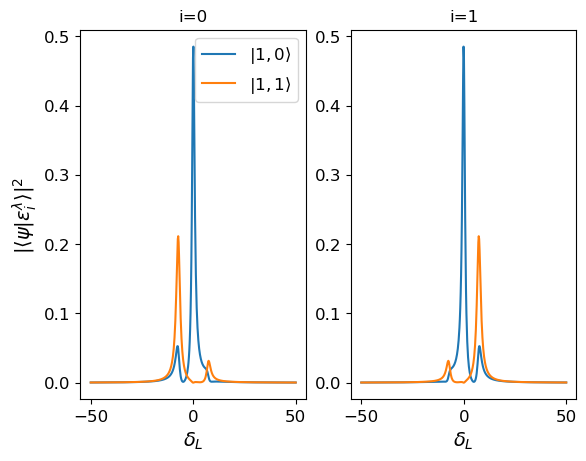

In [25]:
fig = plt.figure(1)
ax = fig.subplots(1,2)
ax[0].plot(δL, np.abs(pt_ovlps_e0_10) ** 2, label='$|1,0\\rangle$')
ax[0].plot(δL, np.abs(pt_ovlps_e0_11) ** 2, label='$|1,1\\rangle$')
ax[0].set_xlabel("$\\delta_L$")
ax[0].set_ylabel("$|\\langle\\psi|\\epsilon_i^\\lambda\\rangle|^2$")
ax[0].set_title("i=0")
ax[0].legend()

ax[1].plot(δL, np.abs(pt_ovlps_e1_10) ** 2)
ax[1].plot(δL, np.abs(pt_ovlps_e1_11) ** 2)
ax[1].set_xlabel("$\\delta_L$")
ax[1].set_title("i=1")

Text(0.5, 0, '$\\delta_L$')

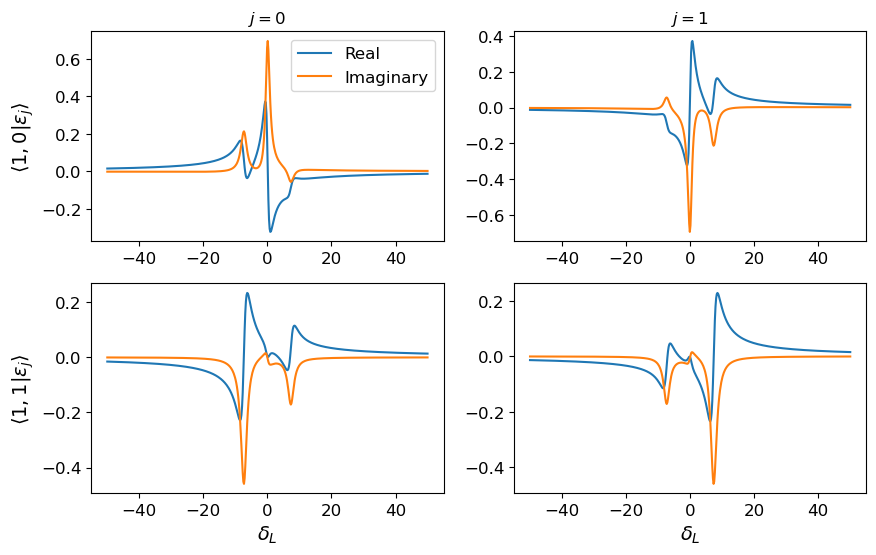

In [26]:
fig = plt.figure(1, figsize=(10,6))
ax = fig.subplots(2,2)
ax[0][0].plot(δL, pt_ovlps_e0_10.real, label='Real')
ax[0][0].plot(δL, pt_ovlps_e0_10.imag, label='Imaginary')
#ax[0].set_xlabel("$\\delta_L$")
ax[0][0].set_ylabel("$\\langle1,0|\\epsilon_j\\rangle$")
ax[0][0].set_title("$j=0$")
ax[0][0].legend()

ax[0][1].plot(δL, pt_ovlps_e1_10.real)
ax[0][1].plot(δL, pt_ovlps_e1_10.imag)
#ax[1].set_xlabel("$\\delta_L$")
ax[0][1].set_title("$j=1$")

ax[1][0].plot(δL, pt_ovlps_e0_11.real)
ax[1][0].plot(δL, pt_ovlps_e0_11.imag)
#ax[1][0].set_title("$n=1, j=0$")
ax[1][0].set_ylabel("$\\langle1,1|\\epsilon_j\\rangle$")
ax[1][0].set_xlabel("$\\delta_L$")

ax[1][1].plot(δL, pt_ovlps_e1_11.real)
ax[1][1].plot(δL, pt_ovlps_e1_11.imag)
#ax[1][1].set_title("$n=1, j=1$")
ax[1][1].set_xlabel("$\\delta_L$")

Text(0, 0.5, '$|\\langle1,0|\\epsilon_j\\rangle + \\langle1,1|\\epsilon_j\\rangle|^2$')

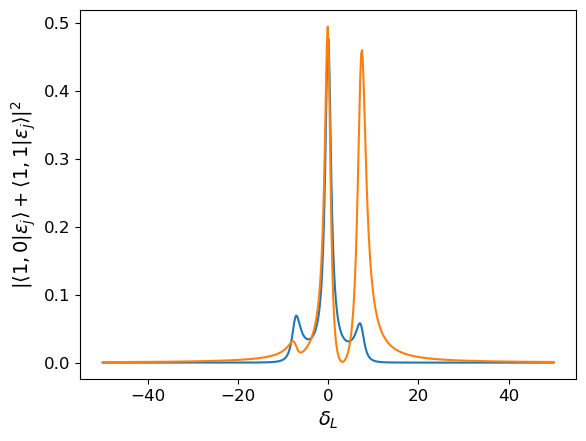

In [27]:
plt.plot(δL, np.abs(pt_ovlps_e0_10 + pt_ovlps_e0_11) ** 2, label='j=0')
plt.plot(δL, np.abs(pt_ovlps_e1_10 + pt_ovlps_e1_11) ** 2, label='j=1')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle1,0|\\epsilon_j\\rangle + \\langle1,1|\\epsilon_j\\rangle|^2$")

Text(0, 0.5, '$\\sum_{n,j}|\\langle1,n|\\epsilon_j\\rangle|^2$')

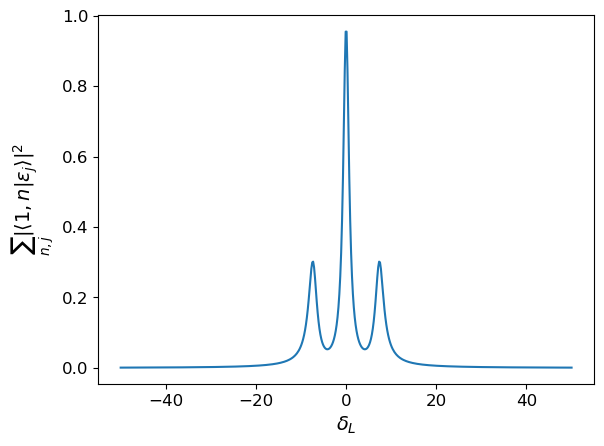

In [28]:
plt.plot(δL, np.abs(pt_ovlps_e0_10) ** 2 + np.abs(pt_ovlps_e0_11) ** 2 + np.abs(pt_ovlps_e1_10) ** 2 + np.abs(pt_ovlps_e1_11) ** 2)
plt.xlabel("$\\delta_L$")
plt.ylabel("$\\sum_{n,j}|\\langle1,n|\\epsilon_j\\rangle|^2$")

These results are pretty strange.  I'm pretty sure that I was able to get results that look like they showcase the dark state using the perturbation theory approach previously, so what gives?  Well, looking back on my previous code, it seems that I wasn't really calculating this system at all.  The Hamiltonian in the inverse term did not correctly include the damping terms and I calculated $|\langle1,0|\frac{1}{\delta_L-H'}|1,0\rangle|^2$ to get the transmission spectrum.  This doesn't really have anything to do with the eigenstates of the system at all, so I was essentially just calculating the system from the Ningyuang paper, which would obviously have the same sort of results that they got.  I outline this and use it to calculate one of the results from before to demonstrate a bit more clearly what I'm talking about here.

In [29]:
# This is the bad Hamiltonian I used in getting the results of the perturbation theory a while ago
bad_H = qu.Qobj([[-1j*κ, g10, 0],
                 [g10, -1j*γ10, g21],
                 [0, g21, -1j*γ21]])
bad_H

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0. -1.j    3.5+0.j    0. +0.j  ]
 [ 3.5+0.j   -0. -1.j    6.5+0.j  ]
 [ 0. +0.j    6.5+0.j   -0. -0.05j]]

Notice how this Hamiltonian is essentially defined on the basis $|1,0\rangle, |1,1\rangle, |0,2\rangle$ but misses the damping term of the cavity on the $|1,1\rangle\langle1,1|$ term.  Also notice how I flipped the sign on the coupling terms.  Now let's use it for to calculate the transmission spectrum as I did back then.

In [30]:
bad_δL = np.linspace(-25, 25, 100)
bad_trans = np.zeros(bad_δL.shape[0], dtype=complex)
for i in range(bad_δL.shape[0]):
    bad_trans[i] = np.abs(κ / 2) ** 2 * np.abs(qu.Qobj([1,0,0]).dag() * (bad_δL[i] * qu.qeye(3) - bad_H).inv() * qu.Qobj([1,0,0])) ** 2

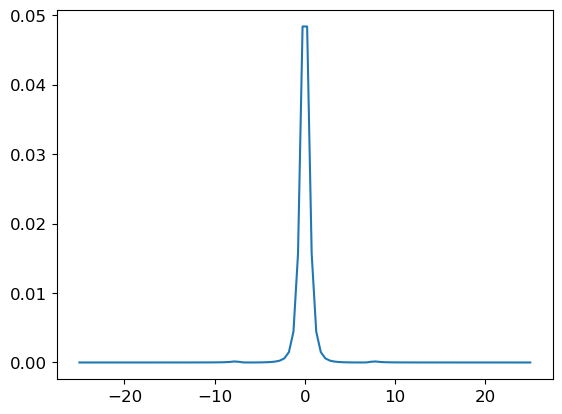

In [31]:
plt.plot(bad_δL, np.abs(bad_trans) ** 2)

### Green's Function Approach
The first attempt is going to involve calculating the exact resolvent using Eq. A.18 from Ch. 3 of Cohen-Tannoudji, and then calculating $|\langle1,0|G(z)|1,0\rangle|^2$ and seeing what we get from that.

In [32]:
def exact_resolvent(z, H):
    return (z - H).inv()

In [33]:
Gs = np.zeros(δL.shape[0], dtype=object)
for i in range(δL.shape[0]):
    Gs[i] = exact_resolvent(δL[i], H0_pt + Vd_pt)

In [34]:
gf_10_ovlp = np.array([np.abs(qu.basis(5,3).dag() * _ * qu.basis(5,3)) ** 2 for _ in Gs])
gf_11_ovlp = np.array([np.abs(qu.basis(5,4).dag() * _ * qu.basis(5,4)) ** 2 for _ in Gs])
gf_mixed_ovlp = np.array([np.abs(qu.basis(5,3).dag() * _ * qu.basis(5,4)) ** 2 for _ in Gs])

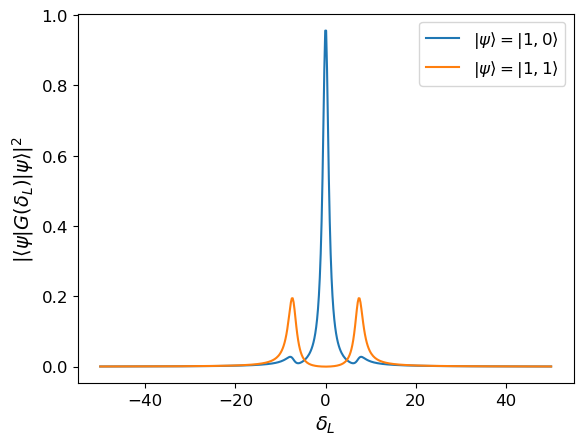

In [35]:
plt.plot(δL, gf_10_ovlp, label='$|\\psi\\rangle=|1,0\\rangle$')
plt.plot(δL, gf_11_ovlp, label='$|\\psi\\rangle=|1,1\\rangle$')
#plt.plot(δL, gf_mixed_ovlp, label='Both')
#plt.plot(δL, gf_10_ovlp + gf_11_ovlp + 2*gf_mixed_ovlp, '--', label='Sum')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|\\langle\\psi|G(δ_L)|\\psi\\rangle|^2$")
plt.legend()

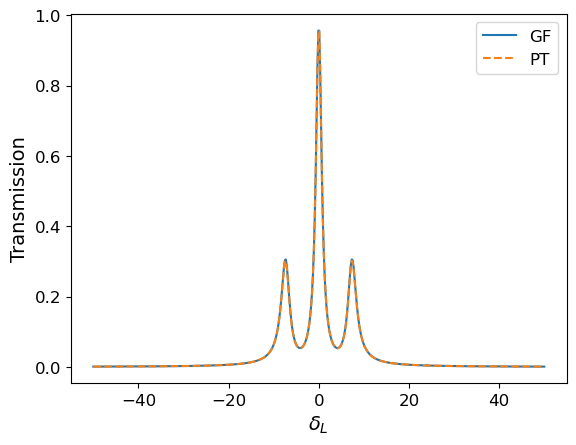

In [36]:
# Compare these results
plt.plot(δL, gf_10_ovlp + gf_11_ovlp + 2*gf_mixed_ovlp, label='GF')
plt.plot(δL, np.abs(pt_ovlps_e0_10) ** 2 + np.abs(pt_ovlps_e0_11) ** 2 + np.abs(pt_ovlps_e1_10) ** 2 + np.abs(pt_ovlps_e1_11) ** 2, '--',
        label='PT')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

Kevin's suggestion is that we should probably only care about plotting $|\langle1,0|G(\delta_L)|1,0\rangle|^2$ and $|\langle1,1|G(\delta_L)|1,1\rangle|^2$.  I'm not entirely sure how that maps to the perturbation theory result yet.  More precisely, the individual calculations $|\langle1,n|e_j^\lambda\rangle|^2$ don't break down the same way.

In [37]:
H0_pt

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. +0.j   3.5+0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [3.5+0.j   0. -1.j   0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. -0.05j 0. +0.j   6.5+0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. -1.j   3.5+0.j  ]
 [0. +0.j   0. +0.j   6.5+0.j   3.5+0.j   0. -2.j  ]]

In [38]:
# Define the Δ1 values we want to check - we'll keep the other detuning on 0 for now
Δ1s = np.array([0, 15, 30])

In [39]:
# Define the Hamiltonians associated with these detunings - this can be done by adding a new term to our old Hamiltonian
Hs_pt = [-_ * (qu.basis(5,1) * qu.basis(5,1).dag() + qu.basis(5,4) * qu.basis(5,4).dag()) + H0_pt for _ in Δ1s]
Hs_pt[2]

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=False
Qobj data =
[[  0. +0.j     3.5+0.j     0. +0.j     0. +0.j     0. +0.j  ]
 [  3.5+0.j   -30. -1.j     0. +0.j     0. +0.j     0. +0.j  ]
 [  0. +0.j     0. +0.j     0. -0.05j   0. +0.j     6.5+0.j  ]
 [  0. +0.j     0. +0.j     0. +0.j     0. -1.j     3.5+0.j  ]
 [  0. +0.j     0. +0.j     6.5+0.j     3.5+0.j   -30. -2.j  ]]

In [40]:
det_Gs = np.zeros((Δ1s.shape[0], δL.shape[0]), dtype=object)
for k in range(Δ1s.shape[0]):
    for i in range(δL.shape[0]):
        det_Gs[k][i] = exact_resolvent(δL[i], Hs_pt[k] + Vd_pt)

In [41]:
det_gf_10_ovlp = [np.array([np.abs(qu.basis(5,3).dag() * _ * qu.basis(5,3)) ** 2 for _ in det_Gs[k]]) for k in range(Δ1s.shape[0])]
det_gf_11_ovlp = [np.array([np.abs(qu.basis(5,4).dag() * _ * qu.basis(5,4)) ** 2 for _ in det_Gs[k]]) for k in range(Δ1s.shape[0])]
det_gf_mixed_ovlp = [np.array([np.abs(qu.basis(5,3).dag() * _ * qu.basis(5,4)) ** 2 for _ in det_Gs[k]]) for k in range(Δ1s.shape[0])]

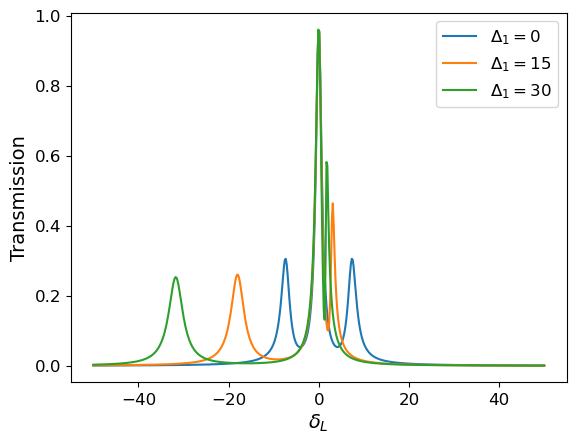

In [42]:
for i in range(Δ1s.shape[0]):
    plt.plot(δL, det_gf_10_ovlp[i] + det_gf_11_ovlp[i] + 2*det_gf_mixed_ovlp[i], label='$\\Delta_1=' + str(Δ1s[i]) + '$')
plt.xlabel("$\\delta_L$")
plt.ylabel("Transmission")
plt.legend()

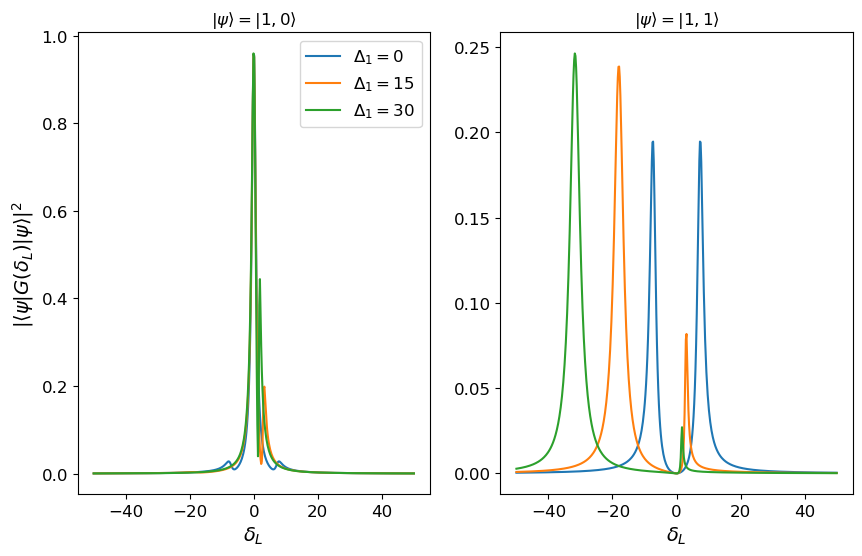

In [43]:
fig = plt.figure(1, figsize=(10,6))
ax = fig.subplots(1,2)
for i in range(Δ1s.shape[0]):
    ax[0].plot(δL, det_gf_10_ovlp[i], label='$\\Delta_1=' + str(Δ1s[i]) + '$')
    ax[1].plot(δL, det_gf_11_ovlp[i])

ax[0].set_ylabel("$|\\langle\\psi|G(\\delta_L)|\\psi\\rangle|^2$")
ax[0].set_xlabel("$\\delta_L$")
ax[0].set_title("$|\\psi\\rangle = |1,0\\rangle$")
ax[0].legend()

ax[1].set_xlabel("$\\delta_L$")
ax[1].set_title("$|\\psi\\rangle = |1,1\\rangle$")
plt.savefig("det_greens_function_results_1atom.png", dpi=300, format='png')

So it looks like the cavity response is basically unchanged when looking at the $\langle1,0|G(\delta_L)|1,0\rangle$ term, but the transmission spectrum shifts from a splitting to a bare cavity when looking at the $\langle1,1|G(\delta_L)|1,1\rangle$.  I think that this makes sense because the detuning doesn't really affect the $|1,0\rangle$ term in the Hamiltonian, but it does affect the $|1,1\rangle$ term.

Now we want to see if we can accurately calculate this using a truncation of the infinite sum in Eq.A.24 in Cohen-Tannoudji.  We should have $G(\delta_L) = G_{H_a} + G_{H_a}VG_{H_a} + G_{H_a}VG_{H_a}VG_{H_a} + \cdots$ where $V$ is the part of the total Hamiltonian describing the interaction between the cavity and the atom.  First, we need to define $H_a$.  This will be done over the basis $|0,2\rangle, |1,0\rangle, |1,1\rangle$, which are arranged to match the order in the previous sections.  This means that we will just use qu.basis(3,0), qu.basis(3,1), and qu.basis(3,2) respectively.  This way we don't have to fiddle with defining the whole thing and then filtering out the states that we don't care about.

In [44]:
# Define Ha
Ha = -1j*γ21 * qu.basis(3,0) * qu.basis(3,0).dag()
Ha += -1j*κ * qu.basis(3,1) * qu.basis(3,1).dag()
Ha += (-1j*κ + -1j*γ10) * qu.basis(3,2) * qu.basis(3,2).dag()
Ha += g10* (qu.basis(3,2) * qu.basis(3,1).dag() + qu.basis(3,1) * qu.basis(3,2).dag())
Ha

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. -0.05j 0. +0.j   0. +0.j  ]
 [0. +0.j   0. -1.j   3.5+0.j  ]
 [0. +0.j   3.5+0.j   0. -2.j  ]]

In [83]:
# Define V
V = g21 * (qu.basis(3,0) * qu.basis(3,2).dag() + qu.basis(3,2) * qu.basis(3,0).dag())
V

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.  0.  6.5]
 [0.  0.  0. ]
 [6.5 0.  0. ]]

In [84]:
# Calculate the exact resolvent
exact_Gs = np.array([exact_resolvent(_, Ha + V) for _ in δL])
exact_Gs[250]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.03621251-0.32690025j -0.06884781+0.52080799j -0.1507733 -0.00476076j]
 [-0.06884781+0.52080799j  0.12343007-0.96989589j -0.00506754+0.00749889j]
 [-0.1507733 -0.00476076j -0.00506754+0.00749889j -0.00228762-0.00123318j]]

In [85]:
G0s = np.array([exact_resolvent(_, Ha) for _ in δL])
G0s[250]

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 7.99038592e+00-3.98720257j  0.00000000e+00+0.j
   0.00000000e+00+0.j        ]
 [ 0.00000000e+00+0.j         -4.06989812e-03-0.14053575j
  -2.45677731e-01-0.00518618j]
 [ 0.00000000e+00+0.j         -2.45677731e-01-0.00518618j
  -5.55166436e-03-0.07034211j]]

In [86]:
j = 250
err = [(exact_Gs[j] - G0s[j]).norm()]
temp = G0s[j]
for i in range(2):
    temp2 = temp * V * G0s[j]
    temp += temp2
    err.append((exact_Gs[j] - temp).norm())

In [87]:
#g0_ovlp_10 = [np.abs(qu.basis(3,1).dag() * (_ + _*V*_ + _*V*_*V*_) * qu.basis(3,1)) ** 2 for _ in G0s]
g0_ovlp_10 = [np.abs(qu.basis(3,1).dag() * (_ + _*V*_) * qu.basis(3,1)) ** 2 for _ in G0s]
#g0_ovlp_11 = [np.abs(qu.basis(3,2).dag() * (_ + _*V*_ + _*V*_*V*_) * qu.basis(3,2)) ** 2 for _ in G0s]
g0_ovlp_11 = [np.abs(qu.basis(3,2).dag() * (_ + _*V*_) * qu.basis(3,2)) ** 2 for _ in G0s]

In [88]:
exact_g_ovlp_10 = [np.abs(qu.basis(3,1).dag() * _ * qu.basis(3,1)) ** 2 for _ in exact_Gs]
exact_g_ovlp_11 = [np.abs(qu.basis(3,2).dag() * _ * qu.basis(3,2)) ** 2 for _ in exact_Gs]

Text(0.5, 1.0, '$|1,1\\rangle$')

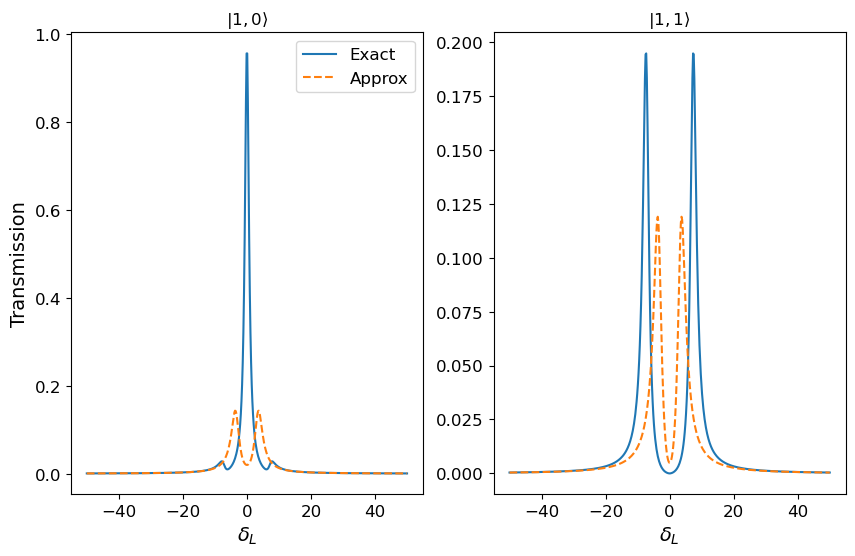

In [89]:
fig = plt.figure(1, figsize=(10,6))
ax = fig.subplots(1,2)
ax[0].plot(δL, exact_g_ovlp_10, label='Exact')
ax[0].plot(δL, g0_ovlp_10, '--', label='Approx')
ax[0].legend()
ax[0].set_xlabel("$\\delta_L$")
ax[0].set_ylabel("Transmission")
ax[0].set_title("$|1,0\\rangle$")

ax[1].plot(δL, exact_g_ovlp_11)
ax[1].plot(δL, g0_ovlp_11, '--', )
ax[1].set_xlabel("$\\delta_L$")
ax[1].set_title("$|1,1\\rangle$")
#plt.savefig("comp_approx_to_exact_gf_2terms_g21=02g10.png", dpi=300, format='png')

So it seems that using the approximate form of Eq. A.25 to calculate the transfer function is not a particularly good match for the exact solution unless $g_{21} \ll g_{10}$.  We kind of thought that might end up being the case, so it's not too terribly surprising.  It is probably worth checking if this changes if we use the level shift function in Eq. B.4 to calculate the exact result using Eq. B.8.

In [56]:
def level_shift(z, ϕb, V, H0_eigs):
    """
    Function for calculating the level shift function
    :param z:       the complex argument of the level shift function
    :param ϕb:      the eigenstate of H0 that we want to calculate the level shift function for
    :param V:       the interaction part of the Hamiltonian
    :param H0_eigs: the eigenstates and eigenvalues of the core part of the Hamiltonian
    :returns:       the value of the level shift function
    """
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([ϕb])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += ϕb.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * ϕb

    return Rx

In [57]:
def four_term_Rx(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    return Rx

In [58]:
def six_term_Rx(z, x, V, H0_eigs):
    # First we need to use a masked array to remove x from the possible eigenstates that we'll sum over
    # Get the index in H0_eigs to exclude
    temp = np.array([x])
    ind_to_exclude = int(np.where(temp == H0_eigs[1])[0][0])

    # Create the masked array
    mask = np.ones(H0_eigs[1][0].shape[0], dtype=bool)

    # Eliminate the unwanted index in the masked array
    mask[ind_to_exclude] = 0

    # Apply the mask to the eigenstates and eigenvalues of H0
    masked_vals = H0_eigs[0][mask]
    masked_states = H0_eigs[1][mask]

    # Now calculate the level shift function
    Rx = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    Rx[i] += x.dag() * V * y * 1 / (z[i] - Ey) * y.dag() * V * p * 1 / (z[i] - Ep) * p.dag() * V * q * 1 / (z[i] - Eq) * q.dag() * V * x

    for i in range(z.shape[0]):
        for Ey, y in zip(masked_vals, masked_states):
            for Ep, p in zip(masked_vals, masked_states):
                for Eq, q in zip(masked_vals, masked_states):
                    for Ek, k in zip(masked_vals, masked_states):
                        for El, l in zip(masked_vals, masked_states):
                            temp = x.dag() * V * y * 1 / (z[i] - Ey)
                            temp *= y.dag() * V * p * 1 / (z[i] - Ep)
                            temp *= p.dag() * V * q * 1 / (z[i] - Eq)
                            temp *= q.dag() * V * k * 1 / (z[i] - Ek)
                            temp *= k.dag() * V * l * 1 / (z[i] - El)
                            temp *= l.dag() * V * x
                            Rx[i] += temp

    return Rx

In [59]:
def resolvent_from_lsf(z, R, Ex):
    """
    Function for evaluating the transfer function from the level shift function
    :param z:  the complex argument that the function varies with
    :param R:  the level shift function values
    :param Ex: the eigenvalue of the eigenstate used in calculating the level shift function
    :returns:  the values of the transfer function
    """
    return 1 / (z - Ex - R)

In [60]:
# Need to define H0
# Define Ha
H0 = -1j*γ10 * qu.basis(5,1) * qu.basis(5,1).dag()
H0 += -1j*γ21 * qu.basis(5,2) * qu.basis(5,2).dag()
H0 += (0-1j*κ) * qu.basis(5,3) * qu.basis(5,3).dag()
H0 += (0-1j*κ + -1j*γ10) * qu.basis(5,4) * qu.basis(5,4).dag()
H0 += g10* (qu.basis(5,0) * qu.basis(5,1).dag() + qu.basis(5,1) * qu.basis(5,0).dag())
H0 += g10* (qu.basis(5,3) * qu.basis(5,4).dag() + qu.basis(5,4) * qu.basis(5,3).dag())
#H0 += λ * (qu.basis(5,0) * qu.basis(5, 3).dag() + qu.basis(5,3) * qu.basis(5,0).dag())
#H0 += λ * (qu.basis(5,1) * qu.basis(5, 4).dag() + qu.basis(5,4) * qu.basis(5,1).dag())
H0

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. +0.j   3.5+0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [3.5+0.j   0. -1.j   0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. -0.05j 0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. -1.j   3.5+0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   3.5+0.j   0. -2.j  ]]

In [61]:
# Get H0 eigenstates
H0_eigs = H0.eigenstates()
H0_eigs

(array([-3.46410162-1.5j , -3.46410162-0.5j ,  0.        -0.05j,
         3.46410162-1.5j ,  3.46410162-0.5j ]),
 array([Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.70710678+0.j        ]
         [-0.69985421-0.10101525j]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.69985421+0.10101525j]
         [ 0.70710678+0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]
         [0.]]                                                                ,
        Quantu

In [62]:
# Define V
V = g21/2 * (qu.basis(5,2) * qu.basis(5,4).dag() + qu.basis(5,4) * qu.basis(5,2).dag())
V += λ * (qu.basis(5,0) * qu.basis(5, 3).dag() + qu.basis(5,3) * qu.basis(5,0).dag())
V += λ * (qu.basis(5,1) * qu.basis(5, 4).dag() + qu.basis(5,4) * qu.basis(5,1).dag())
V

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.00e+00 0.00e+00 0.00e+00 1.00e-03 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00 1.00e-03]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00 3.25e+00]
 [1.00e-03 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 1.00e-03 3.25e+00 0.00e+00 0.00e+00]]

In [63]:
# Calculate the level shift function for each eigenstate
Rs = [level_shift(δL, H0_eigs[1][i], V, H0_eigs) for i in range(H0_eigs[0].shape[0])]
Rs_4terms = [four_term_Rx(δL, H0_eigs[1][i], V, H0_eigs) for i in range(H0_eigs[0].shape[0])]
start = time.time()
Rs_6terms = [six_term_Rx(δL, H0_eigs[1][i], V, H0_eigs) for i in range(H0_eigs[0].shape[0])]
print("Time elaspsed: ", time.time() - start)

Time elaspsed:  57.30318021774292


/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


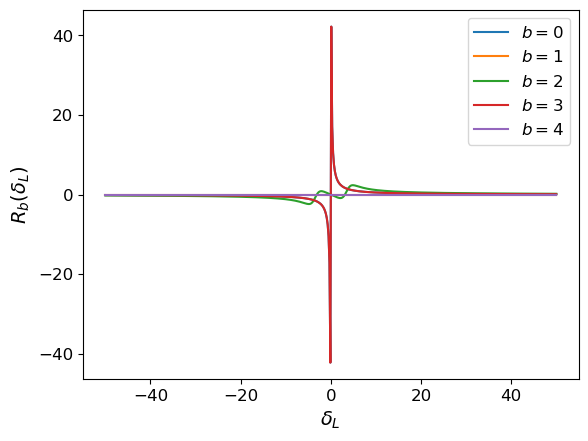

In [64]:
# Plot
for i in range(H0_eigs[0].shape[0]):
    plt.plot(δL, Rs[i], label='$b='+str(i)+'$')
plt.xlabel("$\\delta_L$")
plt.ylabel("$R_b(\\delta_L)$")
plt.legend()

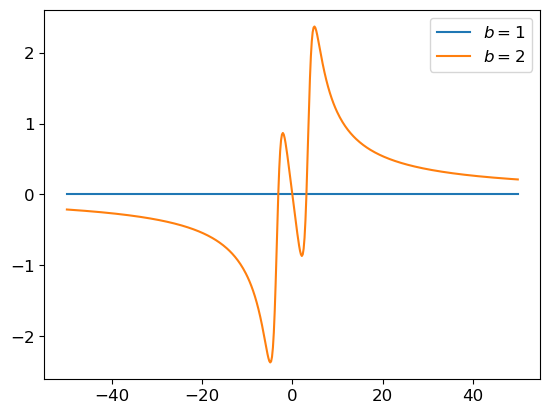

In [95]:
plt.plot(δL, Rs[1], label='$b='+str(1)+'$')
plt.plot(δL, Rs[2], label='$b='+str(2)+'$')
#plt.plot(δL, Rs[4], label='$b='+str(4)+'$')
plt.legend()

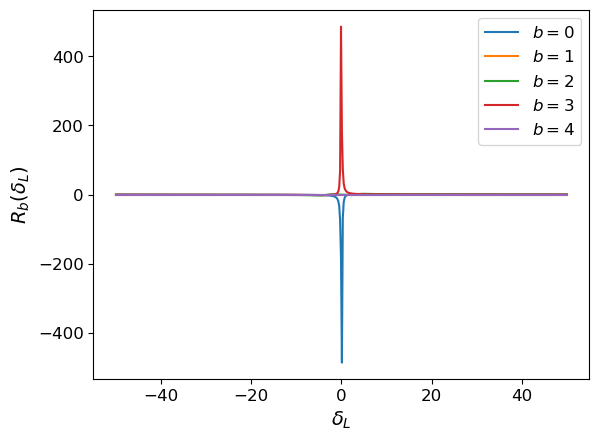

In [65]:
# Plot
for i in range(H0_eigs[0].shape[0]):
    plt.plot(δL, Rs_4terms[i], label='$b='+str(i)+'$')
plt.xlabel("$\\delta_L$")
plt.ylabel("$R_b(\\delta_L)$")
plt.legend()

In [66]:
# Calculate the matrix element of the transfer function corresponding to these eigenstates
lsf_Gs = [1 / (δL - H0_eigs[0][i] - Rs[i]) for i in range(H0_eigs[0].shape[0])]
lsf_Gs_4terms = [1 / (δL - H0_eigs[0][i] - Rs_4terms[i]) for i in range(H0_eigs[0].shape[0])]
lsf_Gs_6terms = [1 / (δL - H0_eigs[0][i] - Rs_6terms[i]) for i in range(H0_eigs[0].shape[0])]

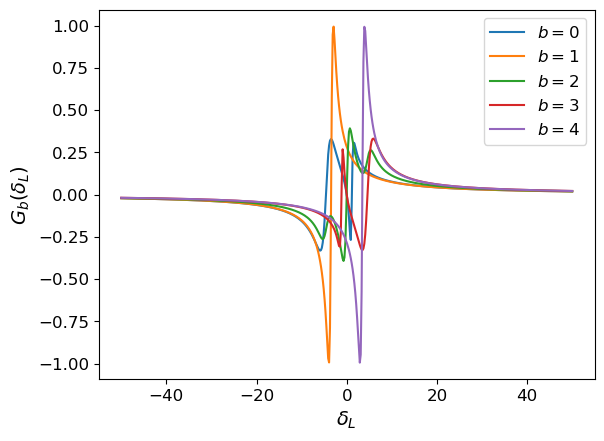

In [67]:
# Plot
for i in range(H0_eigs[0].shape[0]):
    plt.plot(δL, lsf_Gs[i], label='$b='+str(i)+'$')
plt.xlabel("$\\delta_L$")
plt.ylabel("$G_b(\\delta_L)$")
plt.legend()

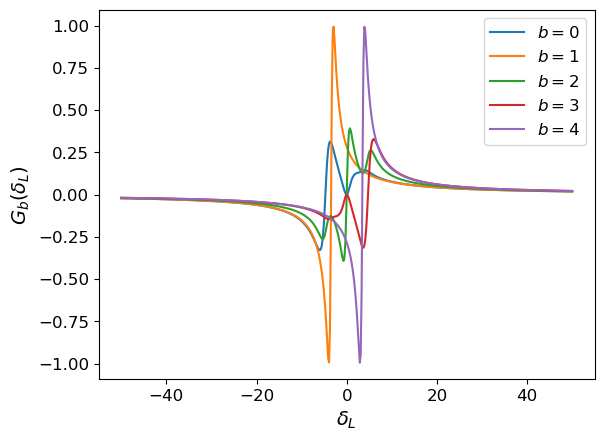

In [68]:
# Plot
for i in range(H0_eigs[0].shape[0]):
    plt.plot(δL, lsf_Gs_4terms[i], label='$b='+str(i)+'$')
plt.xlabel("$\\delta_L$")
plt.ylabel("$G_b(\\delta_L)$")
plt.legend()

In [69]:
# Get the exact resolvent as a function of δL
Gs = [exact_resolvent(_, H0 + V) for _ in δL]

In [70]:
# Get the matrix elements of each in the eigenstate basis corresponding to the eigenstates
ele_Gs = [[H0_eigs[1][i].dag() * _ * H0_eigs[1][i] for _ in Gs] for i in range(H0_eigs[0].shape[0])]

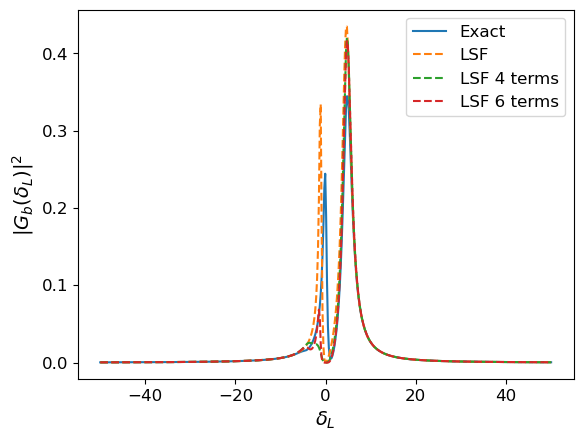

In [71]:
j = 3
plt.plot(δL, np.abs(ele_Gs[j]) ** 2, label='Exact')
plt.plot(δL, np.abs(lsf_Gs[j]) ** 2, '--', label='LSF')
plt.plot(δL, np.abs(lsf_Gs_4terms[j]) ** 2, '--', label='LSF 4 terms')
plt.plot(δL, np.abs(lsf_Gs_6terms[j]) ** 2, '--', label='LSF 6 terms')
plt.xlabel("$\\delta_L$")
plt.ylabel("$|G_b(\\delta_L)|^2$")
plt.legend()

Text(0.5, 1.0, '$b=4$')

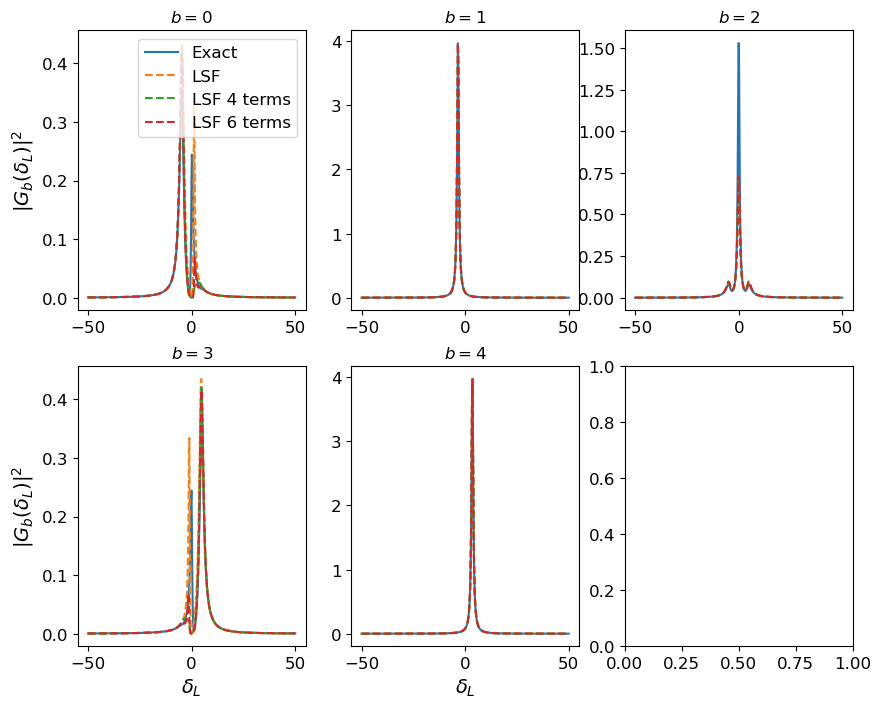

In [72]:
# Plot each
fig = plt.figure(1, figsize=(10,8))
ax = fig.subplots(2,3)
ax[0][0].plot(δL, np.abs(ele_Gs[0]) ** 2, label='Exact')
ax[0][0].plot(δL, np.abs(lsf_Gs[0]) ** 2, '--', label='LSF')
ax[0][0].plot(δL, np.abs(lsf_Gs_4terms[0]) ** 2, '--', label='LSF 4 terms')
ax[0][0].plot(δL, np.abs(lsf_Gs_6terms[0]) ** 2, '--', label='LSF 6 terms')
ax[0][0].set_ylabel("$|G_b(\\delta_L)|^2$")
ax[0][0].set_title("$b=0$")
ax[0][0].legend()
ax[0][1].plot(δL, np.abs(ele_Gs[1]) ** 2)
ax[0][1].plot(δL, np.abs(lsf_Gs[1]) ** 2, '--')
ax[0][1].plot(δL, np.abs(lsf_Gs_4terms[1]) ** 2, '--')
ax[0][1].plot(δL, np.abs(lsf_Gs_6terms[1]) ** 2, '--')
ax[0][1].set_title("$b=1$")
ax[0][2].plot(δL, np.abs(ele_Gs[2]) ** 2)
ax[0][2].plot(δL, np.abs(lsf_Gs[2]) ** 2, '--')
ax[0][2].plot(δL, np.abs(lsf_Gs_4terms[2]) ** 2, '--')
ax[0][2].plot(δL, np.abs(lsf_Gs_6terms[2]) ** 2, '--')
ax[0][2].set_title("$b=2$")
ax[1][0].plot(δL, np.abs(ele_Gs[3]) ** 2)
ax[1][0].plot(δL, np.abs(lsf_Gs[3]) ** 2, '--')
ax[1][0].plot(δL, np.abs(lsf_Gs_4terms[3]) ** 2, '--')
ax[1][0].plot(δL, np.abs(lsf_Gs_6terms[3]) ** 2, '--')
ax[1][0].set_ylabel("$|G_b(\\delta_L)|^2$")
ax[1][0].set_xlabel("$\\delta_L$")
ax[1][0].set_title("$b=3$")
ax[1][1].plot(δL, np.abs(ele_Gs[4]) ** 2)
ax[1][1].plot(δL, np.abs(lsf_Gs[4]) ** 2, '--')
ax[1][1].plot(δL, np.abs(lsf_Gs_4terms[4]) ** 2, '--')
ax[1][1].plot(δL, np.abs(lsf_Gs_6terms[4]) ** 2, '--')
ax[1][1].set_xlabel("$\\delta_L$")
ax[1][1].set_title("$b=4$")

In [90]:
H0_eigs

(array([-3.46410162-1.5j , -3.46410162-0.5j ,  0.        -0.05j,
         3.46410162-1.5j ,  3.46410162-0.5j ]),
 array([Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.70710678+0.j        ]
         [-0.69985421-0.10101525j]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.69985421+0.10101525j]
         [ 0.70710678+0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]
         [ 0.        +0.j        ]]                                           ,
        Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]
         [0.]]                                                                ,
        Quantu

In [91]:
H0

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. +0.j   3.5+0.j   0. +0.j   0. +0.j   0. +0.j  ]
 [3.5+0.j   0. -1.j   0. +0.j   0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. -0.05j 0. +0.j   0. +0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   0. -1.j   3.5+0.j  ]
 [0. +0.j   0. +0.j   0. +0.j   3.5+0.j   0. -2.j  ]]